# Google vs. Baidu — Health Information Framing Analysis

Comparing how Google and Baidu frame health content across topics and sections on dimensions of **specificity**, **TCM stance**, **medical referrals**, and **safety warnings**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

GOOGLE_COLOR = '#4285F4'
BAIDU_COLOR  = '#E02020'

df = pd.read_csv('data/all_google.csv')
print(df.shape)
df.head(3)

(478, 11)


,Unnamed: 0.1,Unnamed: 0,location,query,has_ai_overview,all_items,cited_sources,all_references,paa_questions,topic,section
0,0,0.0,United States,breast cancer,True,['A new lump or mass in the breast or underarm...,[{'title': 'Breast cancer - World Health Organ...,[{'title': 'Breast cancer - Symptoms and cause...,"['What are the top 3 signs of breast cancer?',...",cancer,common_conditions
1,1,1.0,United States,what is cancer,True,['Tumor Formation: Extra cells form masses of ...,"[{'title': 'What Is Cancer? Symptoms, Causes &...",[{'title': 'What Is Cancer? - NCI - National C...,"['What is the simple definition of cancer?', '...",cancer,common_conditions
2,2,2.0,United States,cancer symptoms,True,['Unexplained Weight Loss: Losing $\\ge 10$ po...,[{'title': 'Cancer - Symptoms and causes - May...,[{'title': 'Cancer - Symptoms and causes - May...,"['What are the 7 warning signs for cancer?', '...",cancer,common_conditions


In [4]:
# Basic counts
# print('Platform counts:')
# print(df['platform'].value_counts())
print('\nSection counts:')
print(df['section'].value_counts())
print('\nTopics per section:')
print(df.groupby('section')['topic'].unique().apply(list))


Section counts:
section
common_conditions    120
controversial        120
tcm                  119
legally_variable     116
Name: count, dtype: int64

Topics per section:
section
common_conditions        [cancer, diabetes, hypertension]
controversial        [hantavirus, depression, long_covid]
legally_variable        [gender_affirming, hiv, abortion]
tcm                        [acupuncture, cupping, herbal]
Name: topic, dtype: object


## 1  Specificity — How Detailed Is the Information?

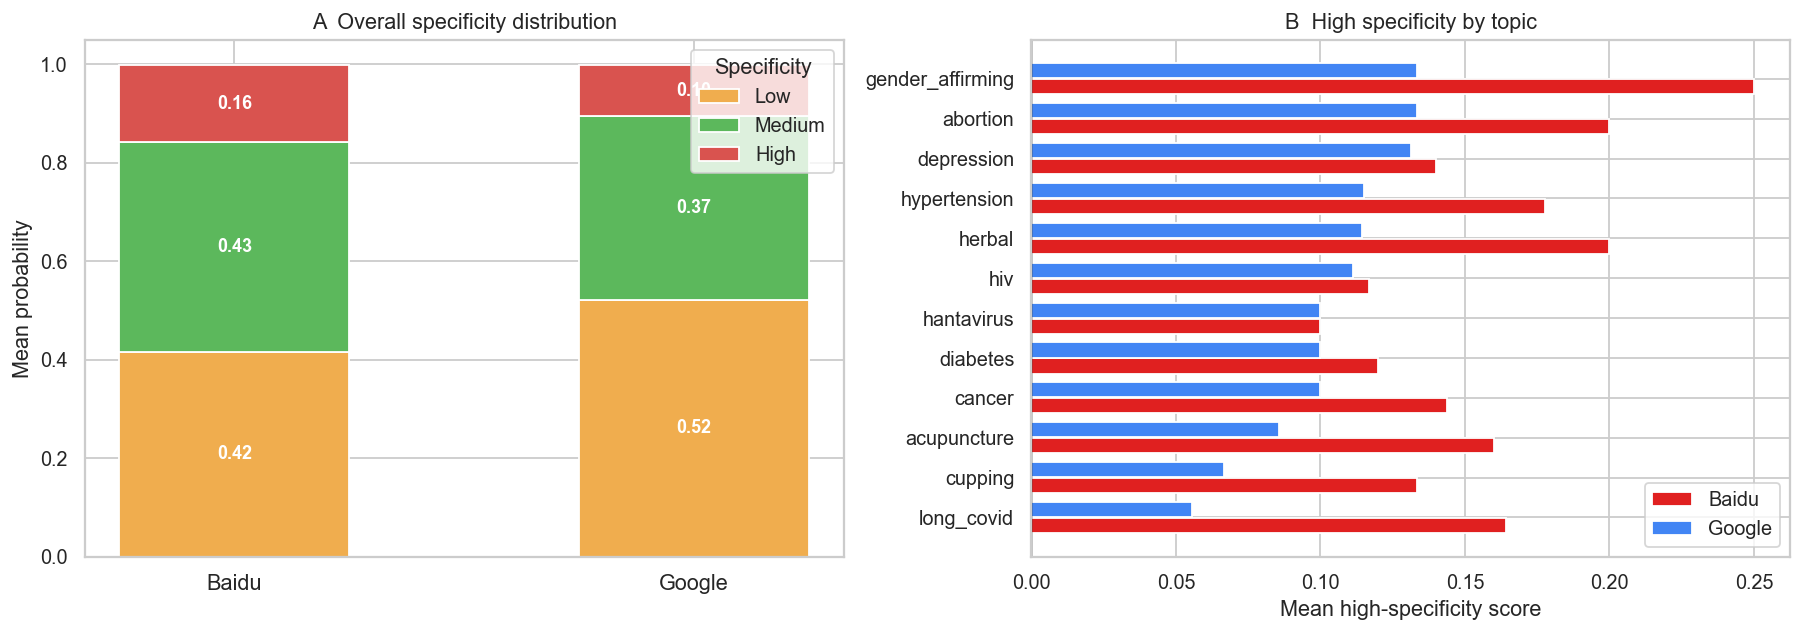

In [3]:
spec_cols = ['specificity_low', 'specificity_medium', 'specificity_high']
spec_labels = ['Low', 'Medium', 'High']
spec_colors = ['#f0ad4e', '#5cb85c', '#d9534f']

# ── Panel A: overall specificity distribution by platform ──────────────────
overall = df.groupby('platform')[spec_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar — overall
ax = axes[0]
x = np.arange(2)
bottom = np.zeros(2)
for col, lbl, clr in zip(spec_cols, spec_labels, spec_colors):
    vals = overall.loc[['baidu', 'google'], col].values
    ax.bar(x, vals, bottom=bottom, label=lbl, color=clr, width=0.5)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.05:
            ax.text(xi, b + v/2, f'{v:.2f}', ha='center', va='center',
                    fontsize=10, color='white', fontweight='bold')
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(['Baidu', 'Google'], fontsize=12)
ax.set_ylabel('Mean probability')
ax.set_title('A  Overall specificity distribution')
ax.legend(title='Specificity', loc='upper right')
ax.set_ylim(0, 1.05)

# ── Panel B: high specificity by topic, both platforms ────────────────────
ax = axes[1]
topic_spec = (df.groupby(['topic', 'platform'])['specificity_high']
                .mean().unstack('platform').fillna(0)
                .sort_values('google', ascending=True))

y = np.arange(len(topic_spec))
ax.barh(y - 0.2, topic_spec.get('baidu', 0), height=0.38,
        color=BAIDU_COLOR, label='Baidu')
ax.barh(y + 0.2, topic_spec.get('google', 0), height=0.38,
        color=GOOGLE_COLOR, label='Google')
ax.set_yticks(y)
ax.set_yticklabels(topic_spec.index)
ax.set_xlabel('Mean high-specificity score')
ax.set_title('B  High specificity by topic')
ax.legend()
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('fig1_specificity.png', bbox_inches='tight')
plt.show()

## 2  TCM Stance — Traditional Chinese Medicine Framing

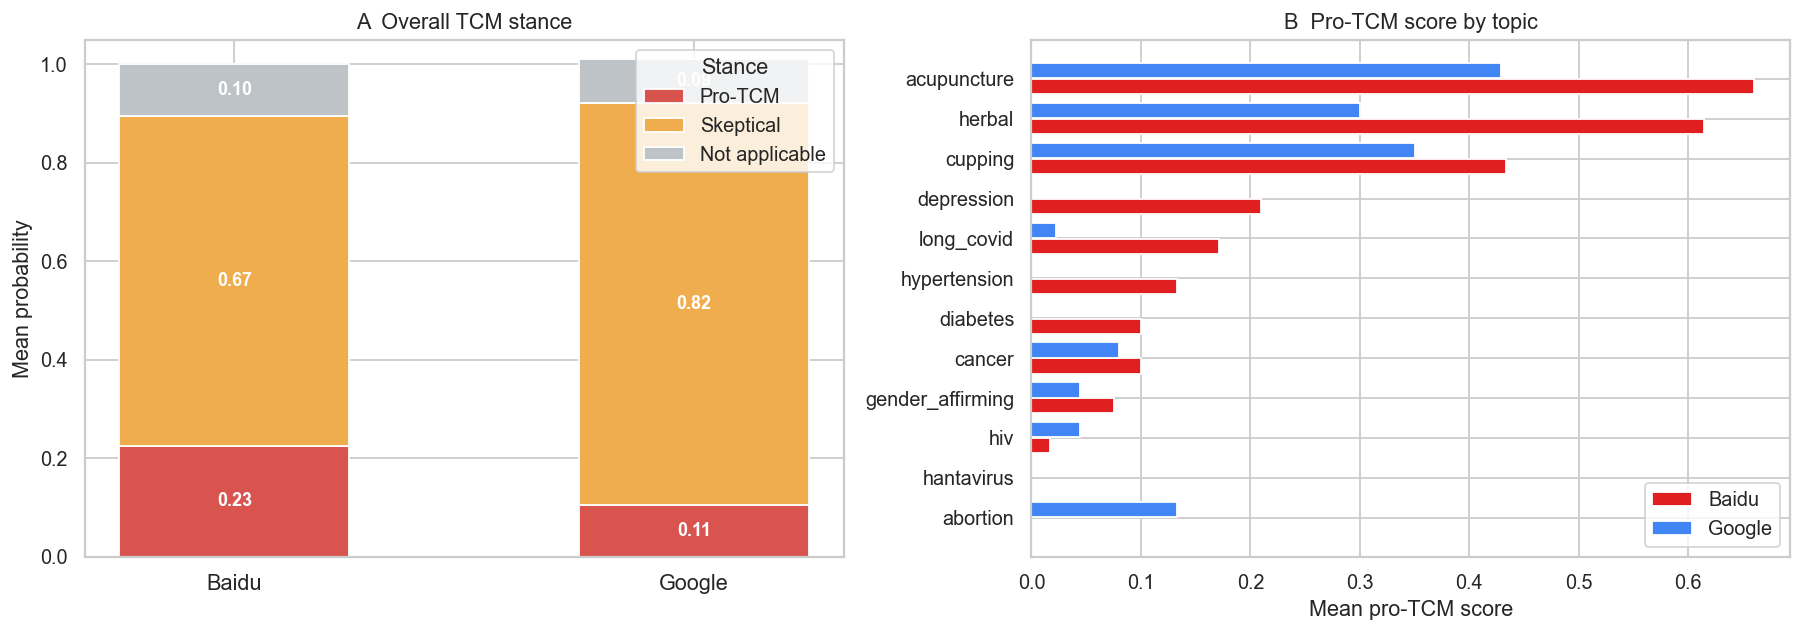

In [4]:
tcm_cols   = ['tcm_pro', 'tcm_skeptical', 'tcm_not_applicable']
tcm_labels = ['Pro-TCM', 'Skeptical', 'Not applicable']
tcm_colors = ['#d9534f', '#f0ad4e', '#BDC3C7']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel A: TCM stance overall ───────────────────────────────────────────
ax = axes[0]
tcm_overall = df.groupby('platform')[tcm_cols].mean()
x = np.arange(2)
bottom = np.zeros(2)
for col, lbl, clr in zip(tcm_cols, tcm_labels, tcm_colors):
    vals = tcm_overall.loc[['baidu', 'google'], col].values
    ax.bar(x, vals, bottom=bottom, label=lbl, color=clr, width=0.5)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.04:
            ax.text(xi, b + v/2, f'{v:.2f}', ha='center', va='center',
                    fontsize=10, color='white', fontweight='bold')
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(['Baidu', 'Google'], fontsize=12)
ax.set_ylabel('Mean probability')
ax.set_title('A  Overall TCM stance')
ax.legend(title='Stance', loc='upper right')
ax.set_ylim(0, 1.05)

# ── Panel B: Pro-TCM score by topic ──────────────────────────────────────
ax = axes[1]
tcm_topic = (df.groupby(['topic', 'platform'])['tcm_pro']
               .mean().unstack('platform').fillna(0)
               .sort_values('baidu', ascending=True))

y = np.arange(len(tcm_topic))
ax.barh(y - 0.2, tcm_topic.get('baidu', 0), height=0.38,
        color=BAIDU_COLOR, label='Baidu')
ax.barh(y + 0.2, tcm_topic.get('google', 0), height=0.38,
        color=GOOGLE_COLOR, label='Google')
ax.set_yticks(y)
ax.set_yticklabels(tcm_topic.index)
ax.set_xlabel('Mean pro-TCM score')
ax.set_title('B  Pro-TCM score by topic')
ax.legend()

plt.tight_layout()
plt.savefig('fig2_tcm_stance.png', bbox_inches='tight')
plt.show()

## 3  Referrals & Safety Warnings

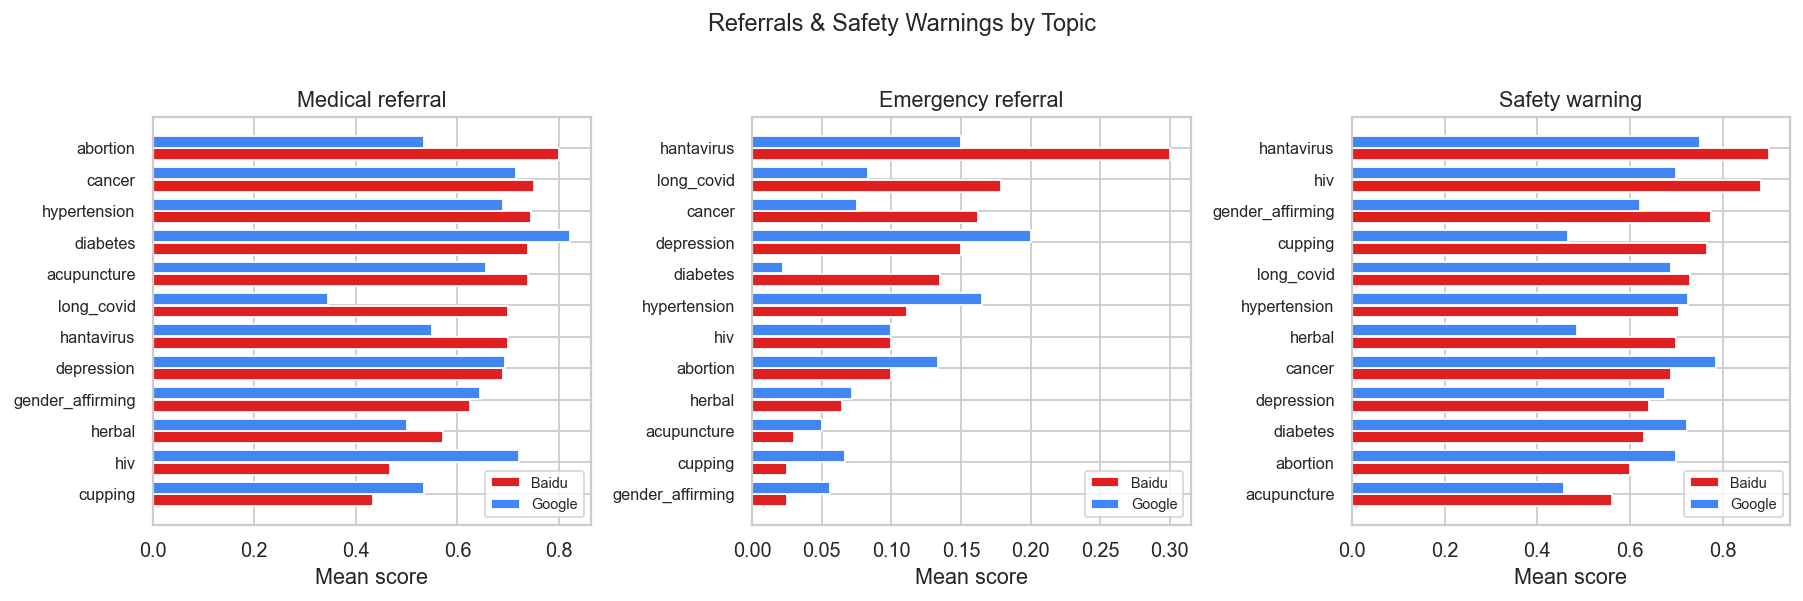

In [5]:
ref_cols   = ['referral_to_medical_profession', 'emergency_referral', 'safety_warning_present']
ref_labels = ['Medical referral', 'Emergency referral', 'Safety warning']

ref_overall = df.groupby('platform')[ref_cols].mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, col, lbl in zip(axes, ref_cols, ref_labels):
    topic_vals = (df.groupby(['topic', 'platform'])[col]
                    .mean().unstack('platform').fillna(0)
                    .sort_values('baidu', ascending=True))
    y = np.arange(len(topic_vals))
    ax.barh(y - 0.2, topic_vals.get('baidu', 0), height=0.38,
            color=BAIDU_COLOR, label='Baidu')
    ax.barh(y + 0.2, topic_vals.get('google', 0), height=0.38,
            color=GOOGLE_COLOR, label='Google')
    ax.set_yticks(y)
    ax.set_yticklabels(topic_vals.index, fontsize=9)
    ax.set_xlabel('Mean score')
    ax.set_title(lbl)
    ax.legend(fontsize=8)

plt.suptitle('Referrals & Safety Warnings by Topic', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig3_referrals_safety.png', bbox_inches='tight')
plt.show()

## 4  Platform Divergence Heatmap — All Metrics by Section

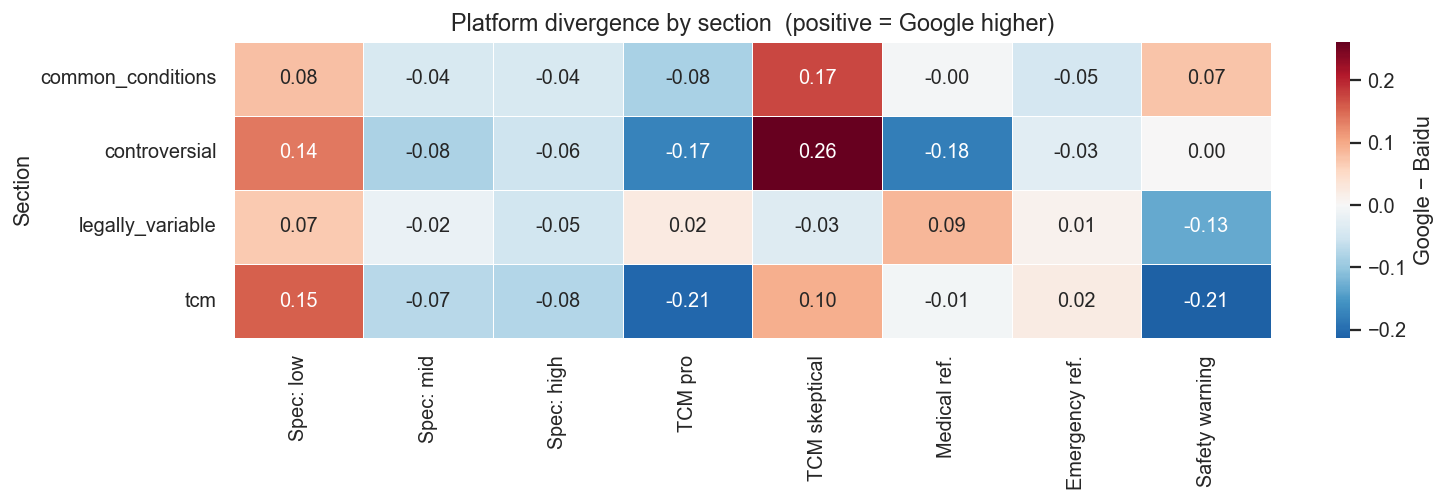

In [6]:
metric_cols = [
    'specificity_low', 'specificity_medium', 'specificity_high',
    'tcm_pro', 'tcm_skeptical',
    'referral_to_medical_profession', 'emergency_referral', 'safety_warning_present'
]
metric_short = [
    'Spec: low', 'Spec: mid', 'Spec: high',
    'TCM pro', 'TCM skeptical',
    'Medical ref.', 'Emergency ref.', 'Safety warning'
]

# Compute (Google − Baidu) per section
grp = df.groupby(['section', 'platform'])[metric_cols].mean()
diff_section = (grp.xs('google', level='platform') -
                grp.xs('baidu',  level='platform'))
diff_section.columns = metric_short

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    diff_section,
    annot=True, fmt='.2f', center=0,
    cmap='RdBu_r', linewidths=0.5,
    cbar_kws={'label': 'Google − Baidu'},
    ax=ax
)
ax.set_title('Platform divergence by section  (positive = Google higher)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Section')
plt.tight_layout()
plt.savefig('fig4_heatmap_section.png', bbox_inches='tight')
plt.show()

## 5  Per-Topic Divergence Heatmap

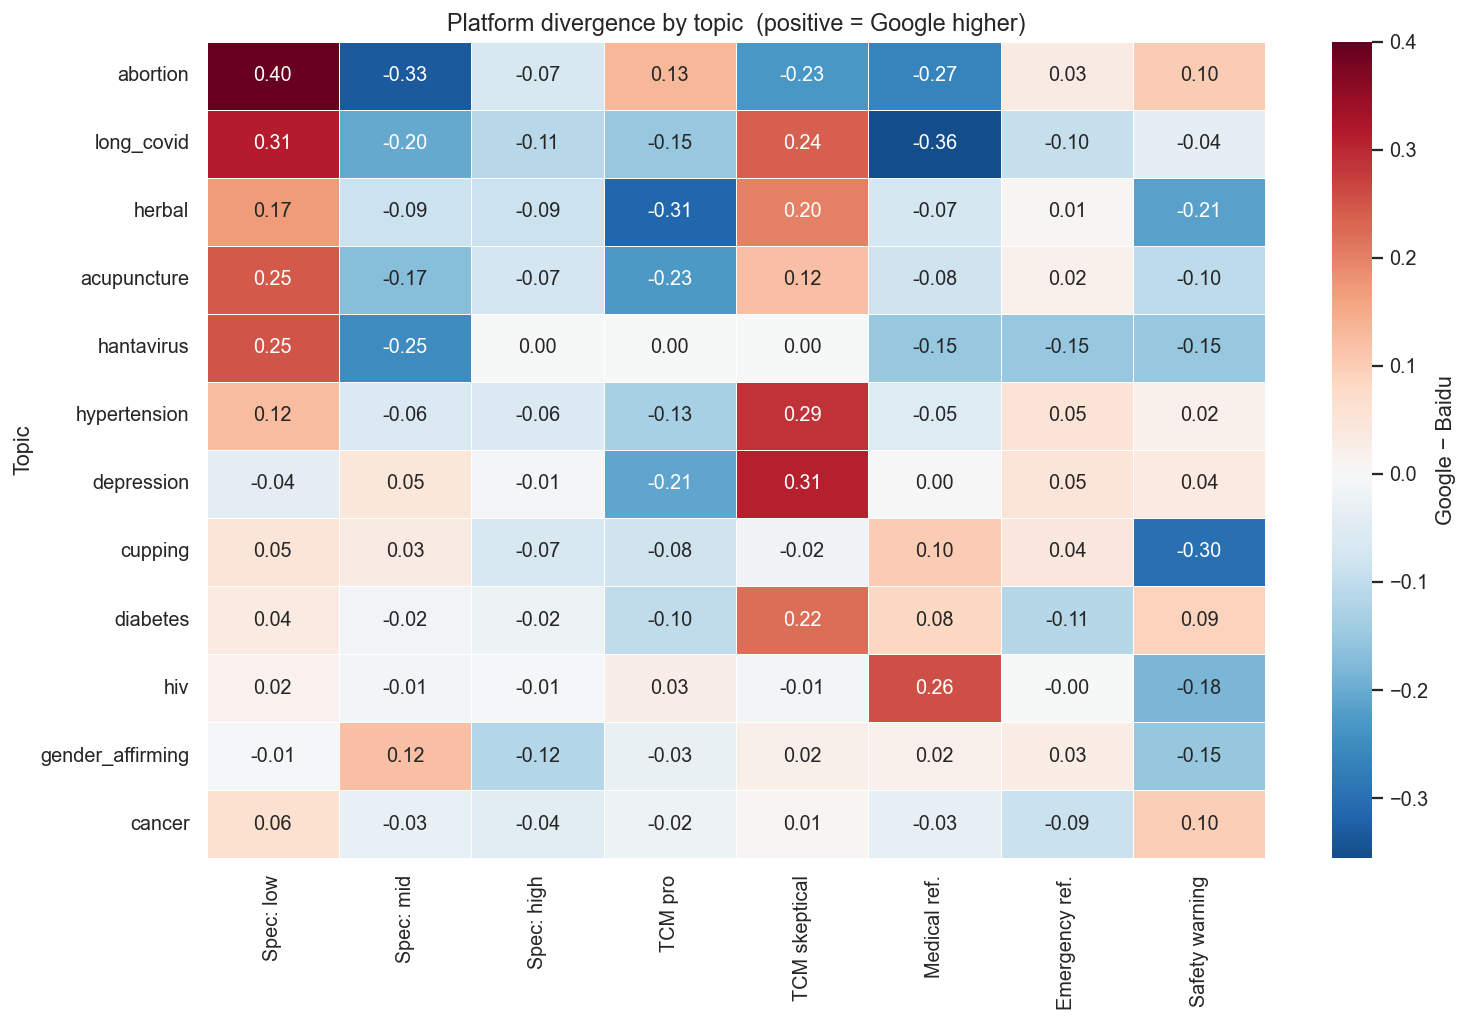

In [7]:
grp_topic = df.groupby(['topic', 'platform'])[metric_cols].mean()
diff_topic = (grp_topic.xs('google', level='platform') -
              grp_topic.xs('baidu',  level='platform'))
diff_topic.columns = metric_short

# Sort rows by total absolute divergence
diff_topic = diff_topic.loc[diff_topic.abs().sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    diff_topic,
    annot=True, fmt='.2f', center=0,
    cmap='RdBu_r', linewidths=0.5,
    cbar_kws={'label': 'Google − Baidu'},
    ax=ax
)
ax.set_title('Platform divergence by topic  (positive = Google higher)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Topic')
plt.tight_layout()
plt.savefig('fig5_heatmap_topic.png', bbox_inches='tight')
plt.show()

## 6  Summary Statistics Table

In [8]:
summary = df.groupby(['section', 'topic', 'platform'])[metric_cols].mean().round(3)
summary.columns = metric_short
summary

Spec: low  Spec: mid  Spec: high  \
section           topic            platform                                     
common_conditions cancer           baidu         0.500      0.356       0.144   
                                   google        0.565      0.325       0.100   
                  diabetes         baidu         0.420      0.460       0.120   
                                   google        0.456      0.444       0.100   
                  hypertension     baidu         0.356      0.467       0.178   
                                   google        0.480      0.405       0.115   
controversial     depression       baidu         0.490      0.370       0.140   
                                   google        0.450      0.419       0.131   
                  hantavirus       baidu         0.400      0.500       0.100   
                                   google        0.650      0.250       0.100   
                  long_covid       baidu         0.321      0.514       0.164   
                                   google        0.633      0.311       0.056   
legally_variable  abortion         baidu         0.200      0.600       0.200   
                                   google        0.600      0.267       0.133   
                  gender_affirming baidu         0.450      0.300       0.250   
                                   google        0.444      0.422       0.133   
                  hiv              baidu         0.450      0.433       0.117   
                                   google        0.467      0.422       0.111   
tcm               acupuncture      baidu         0.340      0.500       0.160   
                                   google        0.586      0.329       0.086   
                  cupping          baidu         0.517      0.333       0.133   
                                   google        0.567      0.367       0.067   
                  herbal           baidu         0.357      0.443       0.200   
                                   google        0.529      0.357       0.114   

                                             TCM pro  TCM skeptical  \
section           topic            platform                           
common_conditions cancer           baidu       0.100          0.862   
                                   google      0.080          0.870   
                  diabetes         baidu       0.100          0.780   
                                   google      0.000          1.000   
                  hypertension     baidu       0.133          0.711   
                                   google      0.000          1.000   
controversial     depression       baidu       0.210          0.690   
                                   google      0.000          1.000   
                  hantavirus       baidu       0.000          1.000   
                                   google      0.000          1.000   
                  long_covid       baidu       0.171          0.729   
                                   google      0.022          0.967   
legally_variable  abortion         baidu       0.000          1.000   
                                   google      0.133          0.767   
                  gender_affirming baidu       0.075          0.875   
                                   google      0.044          0.900   
                  hiv              baidu       0.017          0.933   
                                   google      0.044          0.922   
tcm               acupuncture      baidu       0.660          0.180   
                                   google      0.429          0.300   
                  cupping          baidu       0.433          0.433   
                                   google      0.350          0.417   
                  herbal           baidu       0.614          0.229   
                                   google      0.300          0.429   

                                             Medical ref.  Emergency ref.  \
section       

## 7  Key Findings

In [9]:
print('=== Overall means by platform ===')
print(df.groupby('platform')[metric_cols].mean().T.round(3).rename(columns=str).to_string())

print('\n=== Largest per-topic divergences (|Google − Baidu|) ===')
top_div = diff_topic.abs().max(axis=1).sort_values(ascending=False)
print(top_div.round(3).to_string())

print('\n=== Topics where Baidu is more pro-TCM ===')
tcm_diff = diff_topic['TCM pro'].sort_values()
print(tcm_diff.round(3).to_string())

=== Overall means by platform ===
platform                        baidu  google
specificity_low                 0.415   0.521
specificity_medium              0.427   0.375
specificity_high                0.156   0.103
tcm_pro                         0.225   0.106
tcm_skeptical                   0.671   0.817
referral_to_medical_profession  0.664   0.634
emergency_referral              0.111   0.093
safety_warning_present          0.699   0.653

=== Largest per-topic divergences (|Google − Baidu|) ===
topic
abortion            0.400
long_covid          0.356
herbal              0.314
depression          0.310
cupping             0.300
hypertension        0.289
hiv                 0.256
hantavirus          0.250
acupuncture         0.246
diabetes            0.220
gender_affirming    0.153
cancer              0.097

=== Topics where Baidu is more pro-TCM ===
topic
herbal             -0.314
acupuncture        -0.231
depression         -0.210
long_covid         -0.149
hypertension       -0.

## 8  Section-Level Deep Dive — Google vs. Baidu Within Each Section

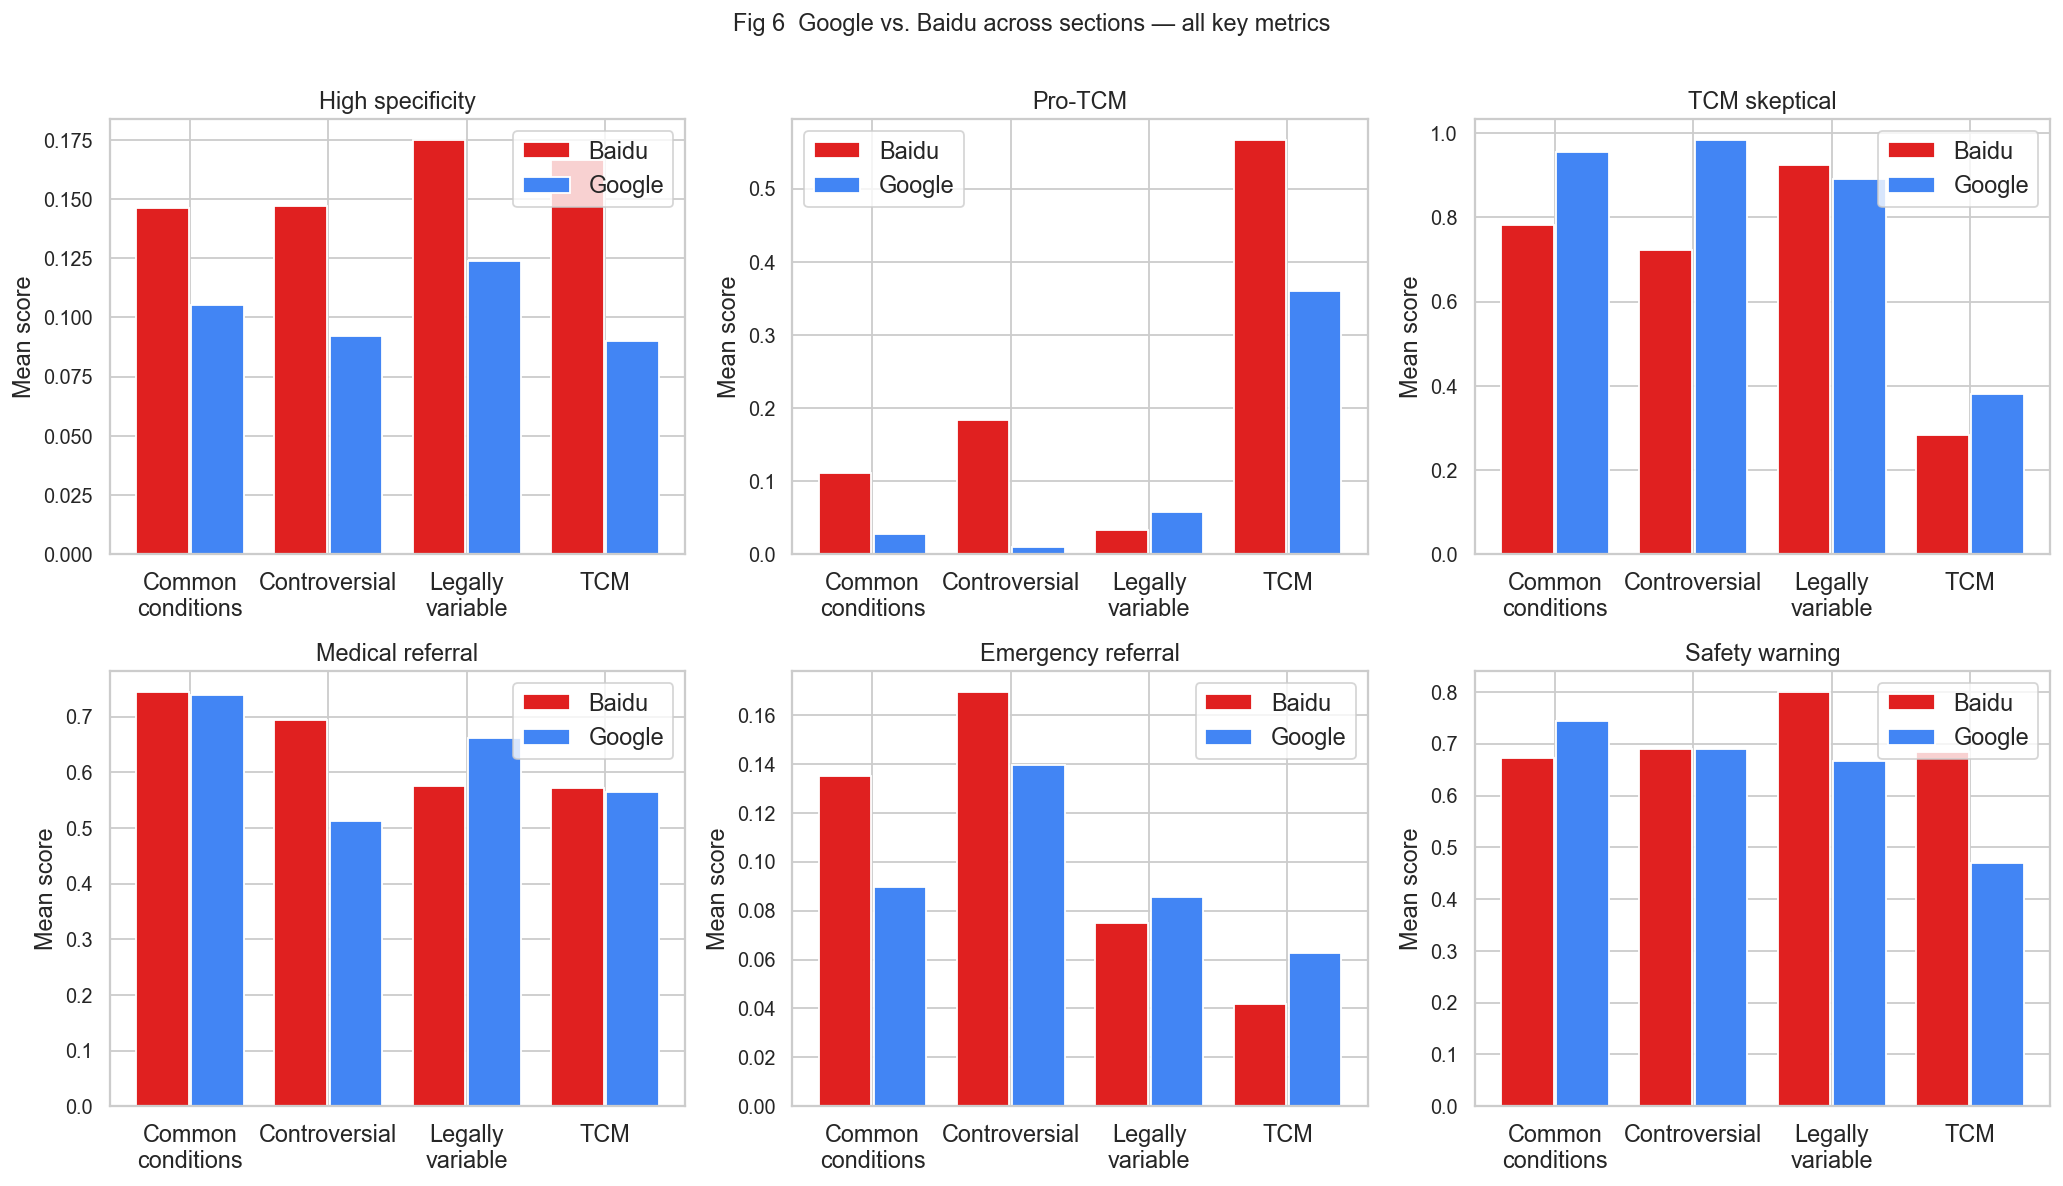

In [16]:

# ── Fig 6: all key metrics by section, grouped bars (Google vs Baidu) ─────
sections = df['section'].unique()
plot_metrics = [
    ('specificity_high',                'High specificity'),
    ('tcm_pro',                         'Pro-TCM'),
    ('tcm_skeptical',                   'TCM skeptical'),
    ('referral_to_medical_profession',  'Medical referral'),
    ('emergency_referral',              'Emergency referral'),
    ('safety_warning_present',          'Safety warning'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
axes = axes.flatten()

for ax, (col, lbl) in zip(axes, plot_metrics):
    sec_vals = (df.groupby(['section', 'platform'])[col]
                  .mean().unstack('platform').fillna(0)
                  .reindex(['common_conditions', 'controversial',
                             'legally_variable', 'tcm']))
    x = np.arange(len(sec_vals))
    ax.bar(x - 0.2, sec_vals.get('baidu',  0), width=0.38,
           color=BAIDU_COLOR,  label='Baidu')
    ax.bar(x + 0.2, sec_vals.get('google', 0), width=0.38,
           color=GOOGLE_COLOR, label='Google')
    ax.set_xticks(x)
    ax.set_xticklabels(
        ['Common\nconditions', 'Controversial', 'Legally\nvariable', 'TCM'],
        fontsize=13
    )
    ax.set_title(lbl, fontsize=13)
    ax.set_ylabel('Mean score', fontsize=13)
    ax.legend(fontsize=13)

plt.suptitle('Fig 6  Google vs. Baidu across sections — all key metrics',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig6_section_metrics.png', bbox_inches='tight')
plt.show()


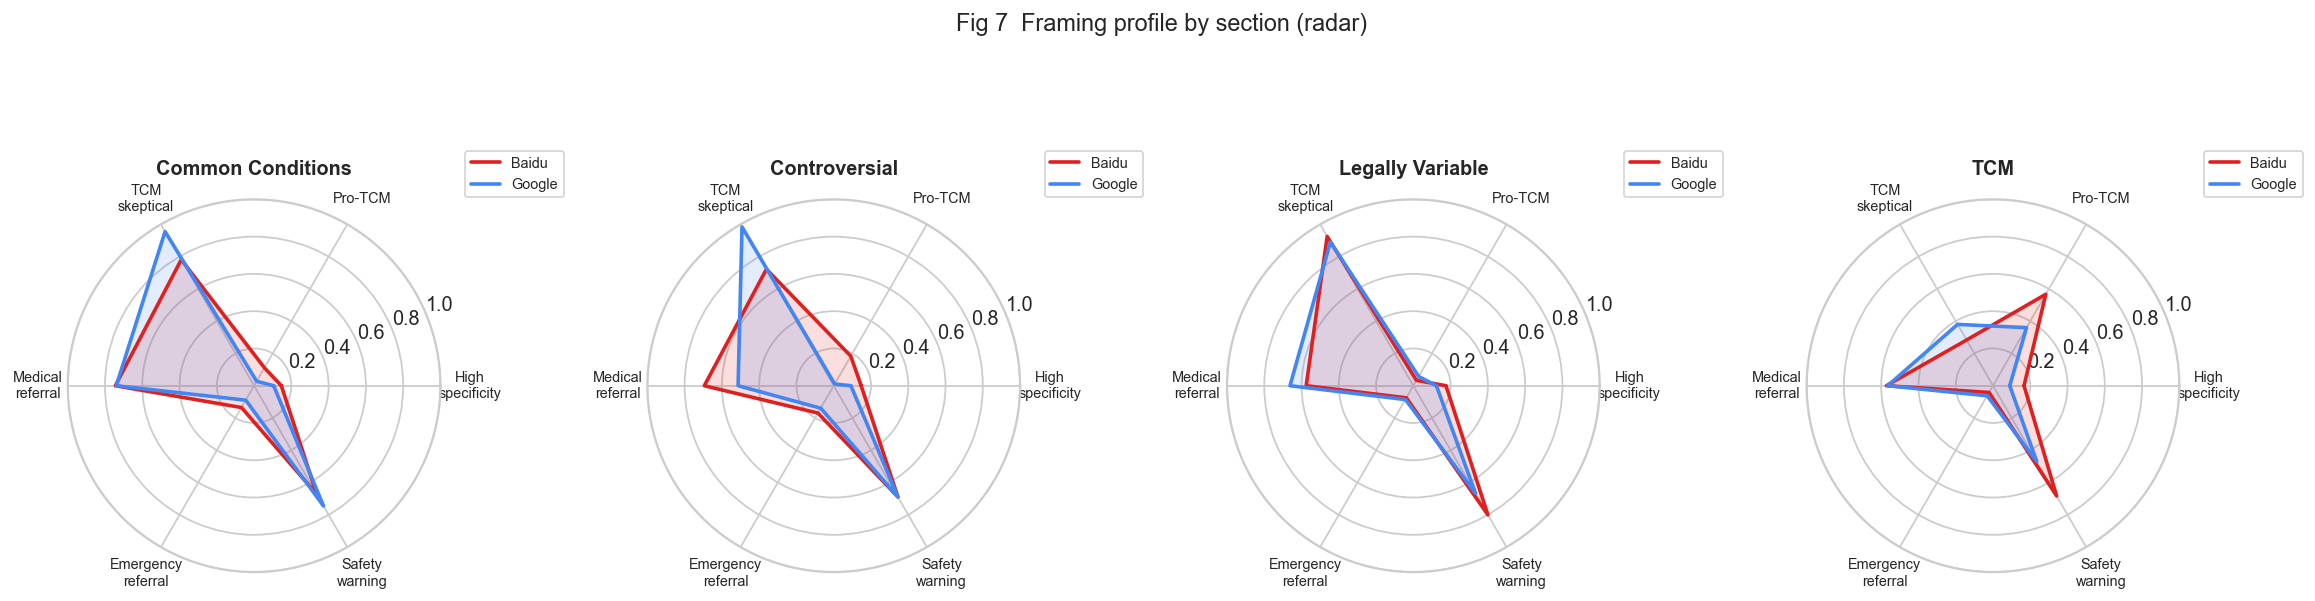

In [11]:

# ── Fig 7: radar chart — one spoke per metric, one polygon per platform,
#           one subplot per section ──────────────────────────────────────────
radar_metrics = [
    'specificity_high', 'tcm_pro', 'tcm_skeptical',
    'referral_to_medical_profession', 'emergency_referral', 'safety_warning_present'
]
radar_labels = [
    'High\nspecificity', 'Pro-TCM', 'TCM\nskeptical',
    'Medical\nreferral', 'Emergency\nreferral', 'Safety\nwarning'
]

section_order = ['common_conditions', 'controversial', 'legally_variable', 'tcm']
section_titles = ['Common Conditions', 'Controversial', 'Legally Variable', 'TCM']

N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(1, 4, figsize=(18, 5),
                         subplot_kw=dict(polar=True))

for ax, sec, title in zip(axes, section_order, section_titles):
    sub = df[df['section'] == sec].groupby('platform')[radar_metrics].mean()
    for platform, color, label in [
        ('baidu',  BAIDU_COLOR,  'Baidu'),
        ('google', GOOGLE_COLOR, 'Google'),
    ]:
        if platform not in sub.index:
            continue
        vals = sub.loc[platform].tolist() + sub.loc[platform].tolist()[:1]
        ax.plot(angles, vals, color=color, linewidth=2, label=label)
        ax.fill(angles, vals, color=color, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=8)
    ax.set_title(title, pad=14, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)

plt.suptitle('Fig 7  Framing profile by section (radar)', fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig('fig7_section_radar.png', bbox_inches='tight')
plt.show()


In [12]:

# ── Section-level summary stats (printed) ─────────────────────────────────
sec_summary = (df.groupby(['section', 'platform'])[metric_cols]
                 .mean().round(3))
sec_summary.columns = metric_short
print(sec_summary.to_string())


                            Spec: low  Spec: mid  Spec: high  TCM pro  TCM skeptical  Medical ref.  Emergency ref.  Safety warning
section           platform                                                                                                        
common_conditions baidu         0.422      0.431       0.146    0.111          0.781         0.744           0.135           0.672
                  google        0.502      0.390       0.105    0.028          0.955         0.740           0.090           0.745
controversial     baidu         0.419      0.433       0.147    0.183          0.722         0.694           0.169           0.689
                  google        0.558      0.350       0.092    0.011          0.984         0.513           0.139           0.689
legally_variable  baidu         0.408      0.417       0.175    0.033          0.925         0.575           0.075           0.800
                  google        0.476      0.400       0.124    0.057          0.89